# Resumen Ejecutivo — Análisis Vintage OC (Moroso-Vencido)

Panorama general del trabajo realizado: proyecciones Chain Ladder de los MOBs faltantes en el vintage histórico,
más las cohortes sintéticas (futuras) para los meses que aún no tienen ventas.

Se presentan dos vistas:
- **General** — proyección ponderada sin segmentar
- **Por Niveles** — proyección ponderada por segmento (CC/PP × Nuevo/Existente × Bajo/Medio/Alto)

> Los valores están expresados como **% de mora** (índice × 100).
> **Verde** = observado | **Naranja** = proyección Chain Ladder | **Gris** = cohorte sintética futura


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

PROJECT_ROOT  = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# Paleta (colores intensos + texto contrastante)
C_OBS   = "#7bc47f"   # verde fuerte = observado
C_PROY  = "#f5b041"   # naranja fuerte = proyectado CL
C_SINT  = "#aeb6bf"   # gris medio = sintética futura
C_HEAD  = "#1c2833"   # header oscuro
T_OBS   = "#1a3a1a"   # texto oscuro sobre verde
T_PROY  = "#4a2800"   # texto oscuro sobre naranja
T_SINT  = "#1c2833"   # texto oscuro sobre gris

def pct(v):
    """Formatea como porcentaje con 1 decimal."""
    if pd.isna(v) or v == 0:
        return ""
    return f"{v*100:.1f}%"

def style_tabla(df_vals, df_tipo, caption=""):
    """Genera HTML con celdas coloreadas según tipo."""
    cols = df_vals.columns.tolist()
    html = f'''<style>
      .rtbl {{border-collapse:collapse; font-size:11px; font-family:monospace; width:100%}}
      .rtbl th {{background:{C_HEAD}; color:white; padding:4px 6px; text-align:center; position:sticky; top:0}}
      .rtbl td {{padding:3px 6px; text-align:center; border:1px solid #dee2e6}}
      .rtbl tr:hover td {{filter:brightness(0.95)}}
      caption {{font-weight:bold; font-size:13px; margin-bottom:4px; text-align:left}}
    </style>
    <table class="rtbl"><caption>{caption}</caption><thead><tr>
      <th>Cohorte</th><th>Tipo</th>'''
    for c in cols:
        html += f'<th>{c.replace("MOB_","M")}</th>'
    html += '</tr></thead><tbody>'
    for idx in df_vals.index:
        html += '<tr>'
        tipo = df_tipo.loc[idx] if idx in df_tipo.index else "sint"
        html += f'<td style="background:{C_HEAD};color:white;font-weight:bold">{idx}</td>'
        if tipo == "sint":
            bg, tc = C_SINT, T_SINT
        elif tipo == "obs":
            bg, tc = C_OBS, T_OBS
        else:
            bg, tc = C_PROY, T_PROY
        html += f'<td style="background:{bg};color:{tc}">{tipo.upper()}</td>'
        for c in cols:
            val = df_vals.loc[idx, c]
            if pd.isna(val) or val == 0:
                html += '<td></td>'
                continue
            t = df_tipo.loc[idx] if idx in df_tipo.index else "sint"
            if t == "sint":
                bg, tc = C_SINT, T_SINT
            elif isinstance(df_tipo, pd.DataFrame):
                bg, tc = (C_OBS, T_OBS) if not df_tipo.loc[idx, c] else (C_PROY, T_PROY)
            else:
                bg, tc = (C_OBS, T_OBS) if t == "obs" else (C_PROY, T_PROY)
            html += f'<td style="background:{bg};color:{tc}">{pct(val)}</td>'
        html += '</tr>'
    html += '</tbody></table>'
    return html

print("Setup OK")

Setup OK


---
## 1. Descripción del Proyecto

| | |
|---|---|
| **Cartera** | Créditos otorgados por OC (Tarjetas de Crédito y Préstamos Personales) |
| **Cohortes históricas** | 2022-01 → 2026-01 (25 cohortes con datos observados) |
| **Dato medido** | Índice de morosidad = moroso / vencido (0% a 100%) |
| **Segmentos** | 12 = Tipo(CC/PP) × Cliente(Nuevo/Existente) × Riesgo(Bajo/Medio/Alto) |
| **Método de proyección** | Chain Ladder (promedio ponderado de link ratios históricos) |
| **Cohortes sintéticas** | Futuras (sin ventas aún): MOB_1 estimado con WMA, curva completa con factores CL |
| **MOB objetivo** | 18 meses (madurez) |

### Flujo del trabajo

```
Datos crudos → Matriz Vintage → Factores CL → Proyección (completar triángulo)
                                             → Sintéticas (cohortes futuras)
```


---
## 2. Proyección General (sin segmentación)

Muestra todas las cohortes históricas con sus MOBs proyectados + las 3 cohortes sintéticas futuras.
**Período CL:** cohortes desde 2024-01 (inicio de ventas OC).


In [2]:
# ── Cargar datos generales ─────────────────────────────────────────────────
proy    = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada.csv"),
                      sep=";", decimal=",", index_col=0)
marca   = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada_marcadores.csv"),
                      sep=";", decimal=",", index_col=0)
sint    = pd.read_csv(os.path.join(PROCESSED_DIR, "cohortes_sinteticas.csv"),
                      sep=";", decimal=",", index_col=0)
sint.index.name = "cohorte"

# Filtrar solo cohortes desde 2024-01
proy_rec  = proy.loc[proy.index >= "2024-01"].copy()
marca_rec = marca.loc[marca.index >= "2024-01"].copy()

# Columnas en común
mob_cols = [c for c in proy_rec.columns if c.startswith("MOB_")]
sint_cols = [c for c in sint.columns if c.startswith("MOB_")]
all_cols  = sorted(set(mob_cols + sint_cols), key=lambda x: int(x.split("_")[1]))

# ── Tabla resumen: MOBs clave ──────────────────────────────────────────────
MOBS_CLAVE = ["MOB_1","MOB_3","MOB_6","MOB_9","MOB_12","MOB_15","MOB_18"]

rows = []
for idx in proy_rec.index:
    row = {"cohorte": idx}
    n_obs  = int((~marca_rec.loc[idx]).sum())
    n_proy = int(marca_rec.loc[idx].sum())
    row["Obs"] = n_obs
    row["CL"]  = n_proy
    row["Sint"]= "-"
    for c in MOBS_CLAVE:
        if c in proy_rec.columns:
            val = proy_rec.loc[idx, c]
            row[c] = f"{val*100:.1f}%" if pd.notna(val) and val > 0 else ""
        else:
            row[c] = ""
    rows.append(row)

for idx in sint.index:
    row = {"cohorte": idx, "Obs": "-", "CL": "-", "Sint": "✓"}
    for c in MOBS_CLAVE:
        if c in sint.columns:
            val = sint.loc[idx, c]
            row[c] = f"{val*100:.1f}%" if pd.notna(val) and val > 0 else ""
        else:
            row[c] = ""
    rows.append(row)

df_res = pd.DataFrame(rows).set_index("cohorte")

# Estilos con colores intensos y texto contrastante
def hl_row(row):
    if row["Sint"] == "✓":
        return [f"background-color:{C_SINT};color:{T_SINT};font-weight:bold"] * len(row)
    if row["CL"] == 0:
        return [f"background-color:{C_OBS};color:{T_OBS}"] * len(row)
    return [f"background-color:{C_PROY};color:{T_PROY}"] * len(row)

display(
    df_res.style
    .apply(hl_row, axis=1)
    .set_caption(
        "PROYECCIÓN GENERAL — MOBs clave | Verde=histórica completa | Naranja=con proyección CL | Gris=sintética futura"
    )
    .set_table_styles([{
        "selector": "caption",
        "props": "font-weight:bold; font-size:13px; text-align:left;"
    }])
)

print(f"\nTotal cohortes históricas (desde 2024-01): {len(proy_rec)}")
print(f"Total cohortes sintéticas (futuras):        {len(sint)}")

,Obs,CL,Sint,MOB_1,MOB_3,MOB_6,MOB_9,MOB_12,MOB_15,MOB_18
cohorte,,,,,,,,,,
2024-01,18,0,-,17.9%,15.7%,16.0%,13.0%,11.8%,11.3%,11.2%
2024-02,18,0,-,14.3%,14.3%,13.7%,13.8%,12.5%,12.0%,12.0%
2024-03,18,0,-,15.1%,12.7%,13.8%,13.3%,12.6%,12.2%,12.2%
2024-04,18,0,-,15.2%,13.3%,16.9%,17.0%,16.0%,15.3%,15.1%
2024-05,18,0,-,13.7%,12.9%,17.3%,18.6%,17.5%,16.4%,15.9%
2024-06,18,0,-,11.2%,13.6%,16.7%,20.7%,19.5%,18.2%,17.5%
2024-07,18,0,-,13.4%,14.4%,17.9%,22.2%,20.7%,19.5%,18.6%
2024-08,18,0,-,15.7%,16.8%,23.5%,24.8%,22.8%,21.5%,20.3%
2024-09,17,1,-,15.6%,17.6%,22.2%,27.0%,24.7%,23.1%,21.8%



Total cohortes históricas (desde 2024-01): 25
Total cohortes sintéticas (futuras):        3


### 2.1 Tabla completa (todos los MOBs)

In [3]:
# Tabla MOB a MOB completa — histórico + sintéticas
all_mobs = [c for c in all_cols if c in mob_cols or c in sint_cols]

# Combinar proy_rec + sint (rellenando NaN para cols faltantes)
df_full = pd.concat([
    proy_rec.reindex(columns=all_mobs),
    sint.reindex(columns=all_mobs)
])

# Construir tipos por celda:
# - para históricas: True = proyectado CL
# - para sintéticas: siempre "sint"
tipo_celda = {}  # idx -> col -> tipo str

for idx in proy_rec.index:
    for c in all_mobs:
        if c not in marca_rec.columns:
            tipo_celda[(idx,c)] = "sint"
        elif marca_rec.loc[idx, c]:
            tipo_celda[(idx,c)] = "cl"
        else:
            tipo_celda[(idx,c)] = "obs"

for idx in sint.index:
    for c in all_mobs:
        tipo_celda[(idx,c)] = "sint"

# Mapeo tipo -> (fondo, texto)
_color_map = {
    "obs":  (C_OBS,  T_OBS),
    "cl":   (C_PROY, T_PROY),
    "sint": (C_SINT, T_SINT),
}

# Generar HTML
leyenda = (
    f'<span style="background:{C_OBS};color:{T_OBS};padding:2px 8px;font-weight:bold">Observado</span> &nbsp;'
    f'<span style="background:{C_PROY};color:{T_PROY};padding:2px 8px;font-weight:bold">Proyección CL</span> &nbsp;'
    f'<span style="background:{C_SINT};color:{T_SINT};padding:2px 8px;font-weight:bold">Sintética futura</span>'
)

mob_headers = "".join(f'<th>{c.replace("MOB_","M")}</th>' for c in all_mobs)
html = f'''
<style>
  .vtbl {{border-collapse:collapse; font-size:10px; font-family:monospace}}
  .vtbl th {{background:{C_HEAD}; color:white; padding:3px 5px; text-align:center; white-space:nowrap}}
  .vtbl td {{padding:2px 5px; text-align:right; border:1px solid #dee2e6; white-space:nowrap; font-weight:bold}}
  .vtbl .ch  {{background:{C_HEAD}; color:white; font-weight:bold; text-align:left}}
  caption {{font-weight:bold;font-size:12px;text-align:left;margin-bottom:4px}}
</style>
<p>{leyenda}</p>
<div style="overflow-x:auto">
<table class="vtbl">
<caption>Proyección General — todos los MOBs (% mora)</caption>
<thead><tr><th>Cohorte</th>{mob_headers}</tr></thead>
<tbody>'''

for idx in df_full.index:
    html += f'<tr><td class="ch">{idx}</td>'
    for c in all_mobs:
        val = df_full.loc[idx, c]
        t   = tipo_celda.get((idx, c), "sint")
        bg, tc = _color_map[t]
        txt = f"{val*100:.1f}%" if pd.notna(val) and val > 0 else ""
        html += f'<td style="background:{bg};color:{tc}">{txt}</td>'
    html += '</tr>'

html += '</tbody></table></div>'
display(HTML(html))

Cohorte,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15,M16,M17,M18
2024-01,17.9%,15.4%,15.7%,15.5%,14.8%,16.0%,14.9%,13.7%,13.0%,12.5%,12.0%,11.8%,11.6%,11.4%,11.3%,11.3%,11.2%,11.2%
2024-02,14.3%,14.6%,14.3%,13.9%,13.5%,13.7%,15.6%,14.6%,13.8%,13.0%,12.6%,12.5%,12.3%,12.1%,12.0%,12.0%,11.9%,12.0%
2024-03,15.1%,13.2%,12.7%,12.2%,12.4%,13.8%,14.5%,14.0%,13.3%,12.9%,12.8%,12.6%,12.3%,12.3%,12.2%,12.1%,12.2%,12.2%
2024-04,15.2%,13.9%,13.3%,13.9%,14.7%,16.9%,17.9%,17.4%,17.0%,16.7%,16.3%,16.0%,15.6%,15.4%,15.3%,15.2%,15.1%,15.1%
2024-05,13.7%,12.1%,12.9%,14.0%,14.8%,17.3%,17.2%,18.8%,18.6%,18.2%,17.8%,17.5%,17.0%,16.6%,16.4%,16.2%,16.0%,15.9%
2024-06,11.2%,12.2%,13.6%,14.6%,15.9%,16.7%,19.4%,21.1%,20.7%,20.4%,19.9%,19.5%,18.9%,18.5%,18.2%,17.9%,17.7%,17.5%
2024-07,13.4%,14.0%,14.4%,16.1%,17.0%,17.9%,22.8%,22.5%,22.2%,21.8%,21.3%,20.7%,20.2%,19.9%,19.5%,19.2%,18.9%,18.6%
2024-08,15.7%,15.2%,16.8%,17.8%,19.1%,23.5%,23.6%,24.9%,24.8%,24.1%,23.4%,22.8%,22.3%,21.8%,21.5%,21.0%,20.6%,20.3%
2024-09,15.6%,17.3%,17.6%,19.2%,21.1%,22.2%,26.1%,27.5%,27.0%,26.1%,25.4%,24.7%,24.1%,23.7%,23.1%,22.6%,22.3%,21.8%
2024-10,17.4%,16.8%,18.1%,20.4%,22.0%,23.4%,27.1%,29.3%,28.6%,27.8%,27.2%,26.6%,26.0%,25.2%,24.6%,24.1%,23.6%,23.2%


### 2.2 Evolución del índice de mora al MOB 18 (ultimate)

C:\Users\skannema\AppData\Local\Temp\ipykernel_62888\3276170781.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(ult_hist.index) + list(ult_sint.index), rotation=45, ha="right", fontsize=8)


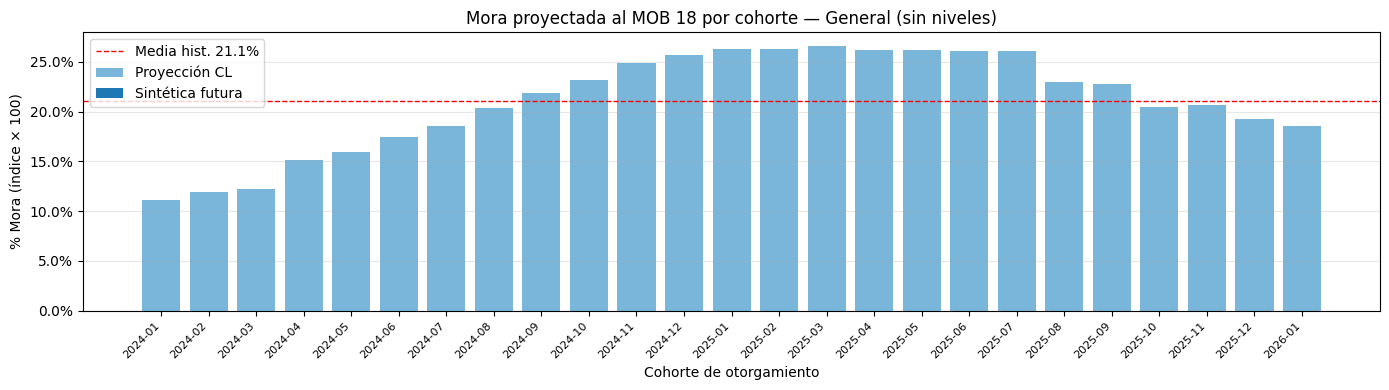

In [4]:
# Barras: mora proyectada al MOB objetivo por cohorte
mob_ult = "MOB_18"
ult_hist  = proy_rec[mob_ult].dropna() if mob_ult in proy_rec.columns else pd.Series(dtype=float)
ult_sint  = sint[mob_ult].dropna() if mob_ult in sint.columns else pd.Series(dtype=float)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(ult_hist.index, ult_hist * 100, color="#6baed6", label="Proyección CL", alpha=0.9)
ax.bar(ult_sint.index, ult_sint * 100, color="#969696", label="Sintética futura", alpha=0.9)
ax.axhline(ult_hist.mean() * 100, color="red", linestyle="--", linewidth=1,
           label=f"Media hist. {ult_hist.mean()*100:.1f}%")
ax.set_title(f"Mora proyectada al MOB 18 por cohorte — General (sin niveles)", fontsize=12)
ax.set_ylabel("% Mora (índice × 100)")
ax.set_xlabel("Cohorte de otorgamiento")
ax.set_xticklabels(list(ult_hist.index) + list(ult_sint.index), rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


---
## 3. Proyección General por Niveles (ponderada por operaciones)

Proyección consolidada de los 12 segmentos, ponderada por cantidad de operaciones.
Toma períodos distintos a la vista general (ventana de datos varía por segmento).


In [5]:
# ── Cargar datos por niveles ───────────────────────────────────────────────
proy_gen = pd.read_csv(os.path.join(PROCESSED_DIR, "proyeccion_general_niveles.csv"),
                       sep=";", decimal=",", index_col=0)
sint_niv = pd.read_csv(os.path.join(PROCESSED_DIR, "sinteticas_general_niveles.csv"),
                       sep=";", decimal=",", index_col=0)
sint_niv.index.name = "cohorte"

# Filtrar sintéticas: solo futuras (no en proy_gen) y con datos (no todos ceros)
sint_niv_ok = sint_niv.loc[
    (~sint_niv.index.isin(proy_gen.index)) & ((sint_niv > 0).any(axis=1))
].copy()

all_cols_niv = sorted(
    set(proy_gen.columns) | set(sint_niv_ok.columns),
    key=lambda x: int(x.split("_")[1]) if x.startswith("MOB_") else 99
)
all_cols_niv = [c for c in all_cols_niv if c.startswith("MOB_")]

# ── Tabla resumen MOBs clave ───────────────────────────────────────────────
MOBS_CLAVE = ["MOB_1","MOB_3","MOB_6","MOB_9","MOB_12","MOB_15","MOB_18"]

rows_niv = []
for idx in sorted(proy_gen.index):
    row = {"cohorte": idx, "Tipo": "Histórica+CL"}
    for c in MOBS_CLAVE:
        val = proy_gen.loc[idx, c] if c in proy_gen.columns else None
        row[c] = f"{val*100:.1f}%" if val and pd.notna(val) and val > 0 else ""
    rows_niv.append(row)

for idx in sorted(sint_niv_ok.index):
    row = {"cohorte": idx, "Tipo": "Sintética"}
    for c in MOBS_CLAVE:
        val = sint_niv_ok.loc[idx, c] if c in sint_niv_ok.columns else None
        row[c] = f"{val*100:.1f}%" if val and pd.notna(val) and val > 0 else ""
    rows_niv.append(row)

df_niv = pd.DataFrame(rows_niv).set_index("cohorte")

def hl_niv(row):
    if row["Tipo"] == "Sintética":
        return [f"background-color:{C_SINT};color:{T_SINT};font-weight:bold"] * len(row)
    return [f"background-color:{C_OBS};color:{T_OBS}"] * len(row)

display(
    df_niv.style
    .apply(hl_niv, axis=1)
    .set_caption(
        "PROYECCIÓN POR NIVELES (ponderada) — MOBs clave | Verde=histórica | Gris=sintética futura"
    )
    .set_table_styles([{
        "selector": "caption",
        "props": "font-weight:bold; font-size:13px; text-align:left;"
    }])
)

print(f"\nCohortes históricas (niveles): {len(proy_gen)}")
print(f"Cohortes sintéticas futuras:   {len(sint_niv_ok)}  ({list(sint_niv_ok.index)})")

,Tipo,MOB_1,MOB_3,MOB_6,MOB_9,MOB_12,MOB_15,MOB_18
cohorte,,,,,,,,
2022-01,Histórica+CL,,,,,,,
2022-02,Histórica+CL,,,,,,,
2022-03,Histórica+CL,,,,,,,
2022-04,Histórica+CL,,,,,,,
2022-05,Histórica+CL,,,,,,,
2022-06,Histórica+CL,,,,,,,
2022-07,Histórica+CL,,,,,,,
2022-08,Histórica+CL,,,,,,,
2022-09,Histórica+CL,,,,,,,



Cohortes históricas (niveles): 49
Cohortes sintéticas futuras:   3  (['2026-02', '2026-03', '2026-04'])


### 3.1 Tabla completa por niveles (todos los MOBs)

In [6]:
# Combinar proy_gen + sint_niv_ok (sin duplicados — sint_niv_ok ya filtrado)
df_full_niv = pd.concat([
    proy_gen.reindex(columns=all_cols_niv),
    sint_niv_ok.reindex(columns=all_cols_niv)
])
df_full_niv = df_full_niv.sort_index()

sint_idx = set(sint_niv_ok.index)

mob_headers_niv = "".join(f'<th>{c.replace("MOB_","M")}</th>' for c in all_cols_niv)

html_niv = f'''
<p>{leyenda}</p>
<div style="overflow-x:auto">
<table class="vtbl">
<caption>Proyección por Niveles — todos los MOBs (% mora, ponderado por operaciones)</caption>
<thead><tr><th>Cohorte</th>{mob_headers_niv}</tr></thead>
<tbody>'''

for idx in df_full_niv.index:
    is_sint = idx in sint_idx
    bg, tc = (C_SINT, T_SINT) if is_sint else (C_OBS, T_OBS)
    html_niv += f'<tr><td class="ch">{idx}</td>'
    for c in all_cols_niv:
        val = df_full_niv.at[idx, c]
        if pd.notna(val) and val > 0:
            txt = f"{val*100:.1f}%"
        else:
            txt = ""
        html_niv += f'<td style="background:{bg};color:{tc}">{txt}</td>'
    html_niv += '</tr>'

html_niv += '</tbody></table></div>'
display(HTML(html_niv))

Cohorte,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15,M16,M17,M18
2022-01,,,,,,,,,,,,,,,,,,
2022-02,,,,,,,,,,,,,,,,,,
2022-03,,,,,,,,,,,,,,,,,,
2022-04,,,,,,,,,,,,,,,,,,
2022-05,,,,,,,,,,,,,,,,,,
2022-06,,,,,,,,,,,,,,,,,,
2022-07,,,,,,,,,,,,,,,,,,
2022-08,,,,,,,,,,,,,,,,,,
2022-09,,,,,,,,,,,,,,,,,,
2022-10,,,,,,,,,,,,,,,,,,


### 3.2 Comparativa: General vs Por Niveles (MOB 18 ultimate)

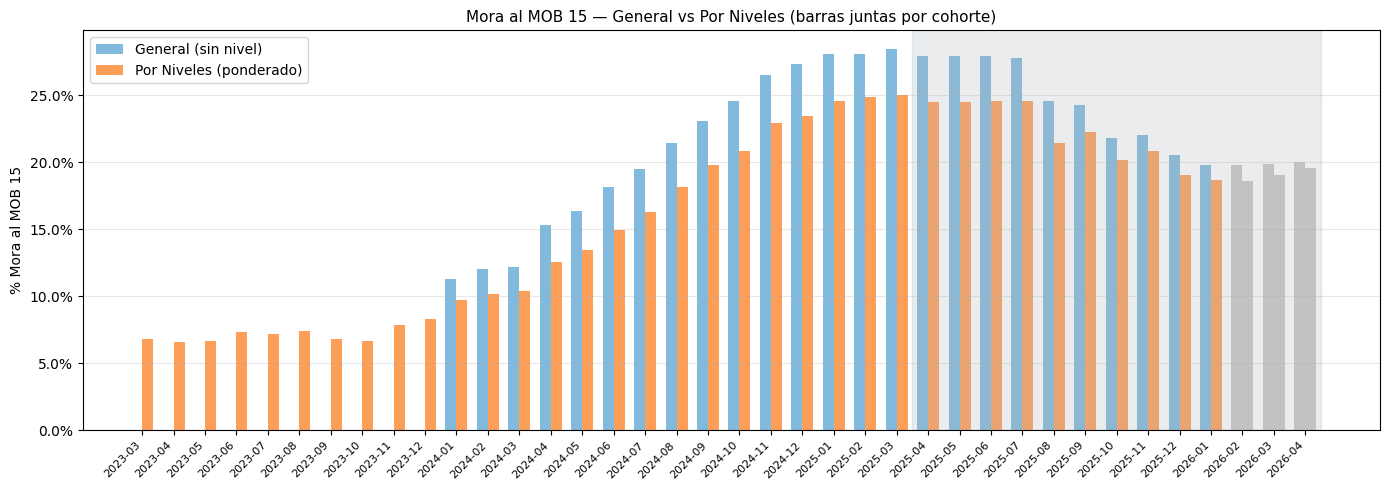


=== SÍNTESIS FINAL ===
  General  — mora media al MOB 15: 22.29%  (últimas 5: 21.70%)
  Niveles  — mora media al MOB 15: 15.99%  (últimas 5: 20.22%)
  Sint. General  — MOB 15 prom:   19.90%
  Sint. Niveles  — MOB 15 prom:   19.10%


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

mob_ult = "MOB_15"
ult_gen  = proy_rec[mob_ult].dropna() if mob_ult in proy_rec.columns else pd.Series(dtype=float)
ult_niv  = proy_gen[mob_ult].dropna() if mob_ult in proy_gen.columns else pd.Series(dtype=float)
ult_sg   = sint[mob_ult].dropna()     if mob_ult in sint.columns else pd.Series(dtype=float)
ult_sn   = sint_niv_ok[mob_ult].dropna() if mob_ult in sint_niv_ok.columns else pd.Series(dtype=float)

x_all = sorted(set(ult_gen.index) | set(ult_niv.index) | set(ult_sg.index) | set(ult_sn.index))
x_num = np.arange(len(x_all))
x_map = {c: i for i, c in enumerate(x_all)}

w = 0.35
ax.bar([x_map[c] - w/2 for c in ult_gen.index],
       ult_gen.values * 100, w, label="General (sin nivel)", color="#6baed6", alpha=0.85)
ax.bar([x_map[c] + w/2 for c in ult_niv.index],
       ult_niv.values * 100, w, label="Por Niveles (ponderado)", color="#fd8d3c", alpha=0.85)
# Sintéticas
ax.bar([x_map[c] - w/2 for c in ult_sg.index],
       ult_sg.values * 100, w, color="#bdbdbd", alpha=0.85)
ax.bar([x_map[c] + w/2 for c in ult_sn.index],
       ult_sn.values * 100, w, color="#bdbdbd", alpha=0.85)

ax.set_xticks(x_num)
ax.set_xticklabels(x_all, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% Mora al MOB 15")
ax.set_title("Mora al MOB 15 — General vs Por Niveles (barras juntas por cohorte)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.axvspan(len(ult_gen) - 0.5, len(x_all) - 0.5,
           color=C_SINT, alpha=0.25, label="Zona sintética")
plt.tight_layout(); plt.show()

print("\n=== SÍNTESIS FINAL ===")
print(f"  General  — mora media al MOB 15: {ult_gen.mean()*100:.2f}%  (últimas 5: {ult_gen.tail(5).mean()*100:.2f}%)")
print(f"  Niveles  — mora media al MOB 15: {ult_niv.mean()*100:.2f}%  (últimas 5: {ult_niv.tail(5).mean()*100:.2f}%)")
if not ult_sg.empty:
    print(f"  Sint. General  — MOB 15 prom:   {ult_sg.mean()*100:.2f}%")
if not ult_sn.empty:
    print(f"  Sint. Niveles  — MOB 15 prom:   {sint_niv_ok.get('MOB_15', pd.Series()).mean()*100:.2f}%")


---
## 4. Sintéticas por Segmento (detalle)

Mora proyectada de las cohortes futuras para cada uno de los 12 segmentos.


In [8]:
sint_seg = pd.read_csv(os.path.join(PROCESSED_DIR, "sinteticas_niveles.csv"),
                       sep=";", decimal=",")

MOBS_CLAVE_S = ["MOB_1","MOB_3","MOB_6","MOB_9","MOB_12","MOB_15"]
COLOR_NIVEL = {"Bajo": "#5cb85c", "Medio": "#f0ad4e", "Alto": "#d9534f"}
TEXTO_NIVEL = {"Bajo": "#1a3a1a", "Medio": "#4a2800", "Alto": "#ffffff"}

rows_seg = []
for seg in sorted(sint_seg["segmento"].unique()):
    df_s = sint_seg[sint_seg["segmento"] == seg].copy()
    for _, r in df_s.iterrows():
        row = {"segmento": seg, "cohorte": r["cohorte"]}
        for c in MOBS_CLAVE_S:
            val = r.get(c, None)
            row[c] = f"{val*100:.1f}%" if val and pd.notna(val) and val > 0 else "—"
        rows_seg.append(row)

df_seg = pd.DataFrame(rows_seg).set_index(["segmento", "cohorte"])

def hl_seg(row):
    idx = row.name[0] if isinstance(row.name, tuple) else ""
    nivel = idx.split("_")[-1] if "_" in str(idx) else ""
    bg = COLOR_NIVEL.get(nivel, "white")
    tc = TEXTO_NIVEL.get(nivel, "#212529")
    return [f"background-color:{bg};color:{tc};font-weight:bold"] * len(row)

display(
    df_seg.style
    .apply(hl_seg, axis=1)
    .set_caption(
        "Cohortes sintéticas por segmento — MOBs clave | Verde=Bajo | Naranja=Medio | Rojo=Alto"
    )
    .set_table_styles([
        {"selector": "caption", "props": "font-weight:bold; font-size:13px; text-align:left;"},
        {"selector": "th", "props": "background:#1c2833; color:white;"}
    ])
)